# 01 - VietNews Data Check (Processed Dataset)

This notebook answers 3 core questions:
1. Is the dataset healthy?
2. Is preprocessing consistent with the frozen protocol?
3. Is the distribution reasonable?

Scope:
- Load **processed** VietNews split
- Read `dataset_manifest.json`
- Validate processed schema
- Validate preprocessing consistency (meta vs recomputed checks)
- Analyze text/sentence length statistics
- Analyze ground-truth compression ratio
- Visualize distributions with histograms
- Inspect random samples

Usage:
- Set `TARGET_SPLIT` to `train`, `validation`, or `test`
- Run all cells top-to-bottom
- For very large splits, keep recomputation checks on a sample only

In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 220)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Environment ready. SEED=", SEED)

Environment ready. SEED= 42


In [2]:
# 1) Load processed dataset + manifest
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "vietnews"
MANIFEST_PATH = PROCESSED_DIR / "dataset_manifest.json"

if not PROCESSED_DIR.exists():
    raise FileNotFoundError(f"Processed directory not found: {PROCESSED_DIR}")
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Manifest not found: {MANIFEST_PATH}")

print("REPO_ROOT:", REPO_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("Available files:", sorted(p.name for p in PROCESSED_DIR.glob("*")))

with MANIFEST_PATH.open("r", encoding="utf-8") as f:
    manifest = json.load(f)

print("\nManifest quick view:")
print(" protocol_version:", manifest.get("protocol_version"))
print(" created_utc:", manifest.get("created_utc"))
print(" output_dir:", manifest.get("output_dir"))
print(" splits:", list((manifest.get("splits") or {}).keys()))

TARGET_SPLIT = "train"  # train / validation / test
SPLIT_FILE = PROCESSED_DIR / f"{TARGET_SPLIT}.jsonl"
if not SPLIT_FILE.exists():
    raise FileNotFoundError(f"Processed split file not found: {SPLIT_FILE}")

MAX_ROWS = None  # optionally set an integer for quick iteration

rows = []
with SPLIT_FILE.open("r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        rows.append(json.loads(line))
        if MAX_ROWS is not None and i + 1 >= MAX_ROWS:
            break

df = pd.DataFrame(rows)
print(f"\nLoaded processed split={TARGET_SPLIT}, rows={len(df):,}, cols={len(df.columns)}")
df.head(2)

REPO_ROOT: C:\Users\OS\OneDrive\Desktop\Text_Summarization
PROCESSED_DIR: C:\Users\OS\OneDrive\Desktop\Text_Summarization\data\processed\vietnews
Available files: ['dataset_manifest.json', 'test.jsonl', 'train.jsonl', 'validation.jsonl']

Manifest quick view:
 protocol_version: phase0_v1
 created_utc: 2026-04-17T02:07:43.917702+00:00
 output_dir: C:\Users\OS\OneDrive\Desktop\Text_Summarization\data\processed\vietnews
 splits: ['train', 'validation', 'test']

Loaded processed split=train, rows=5, cols=5


,guid,title,article,reference_summary,meta
0,28757,Lý_do Jordan đề_nghị quân Chính_phủ Syria hoãn chiến_dịch ở Dara,"Tờ Al_Masdar_News dẫn một nguồn tin quân_đội cho_hay , Jordan vừa đề_nghị quân SAA trì_hoãn chiến_dịch càn_quét sắp tới tại Dara nhằm thuyết_phục các lực_lượng phiến quân hoà_giải với quân Chính_phủ . Nguồn_tin cho b...",Chính_quyền Jordan vừa yêu_cầu quân_đội Chính_phủ Syria ( SAA ) tạm trì_hoãn chiến_dịch quân_sự sắp tới tại Dara .,"{'protocol_version': 'phase0_v1', 'article_char_len': 1994, 'reference_summary_char_len': 114, 'article_sentence_count': 13, 'reference_summary_sentence_count': 1}"
1,40014,Kim_Jong-un hôm_nay có_thể sang Nga họp thượng_đỉnh với Putin,"Tổng_thống Nga_Putin ( trái ) và lãnh_đạo Triều_Tiên_Kim_Jong-un . Hãng thông_tấn trung_ương Triều_Tiên KCNA hôm_nay xác_nhận lãnh_đạo Kim_Jong-un "" sẽ sớm thăm Liên_bang Nga theo lời mời "" của Tổng_thống Vladimir_Pu...","Triều_Tiên xác_nhận Kim_Jong-un "" sớm "" thăm Nga , trong khi truyền_thông Hàn_Quốc đưa tin Kim hôm_nay sẽ lên tàu_hoả tới Nga .","{'protocol_version': 'phase0_v1', 'article_char_len': 1455, 'reference_summary_char_len': 127, 'article_sentence_count': 13, 'reference_summary_sentence_count': 1}"


In [3]:
# 2) Validate processed schema
required_cols = ["guid", "title", "article", "reference_summary", "meta"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

required_meta_keys = [
    "protocol_version",
    "article_char_len",
    "reference_summary_char_len",
    "article_sentence_count",
    "reference_summary_sentence_count",
]

def _has_meta_key(meta: object, key: str) -> bool:
    return isinstance(meta, dict) and key in meta

schema_report = []
for col in required_cols:
    null_count = int(df[col].isna().sum())
    empty_count = int((df[col].fillna("").astype(str).str.strip() == "").sum()) if col != "meta" else 0
    schema_report.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "null_count": null_count,
        "empty_count": empty_count,
        "empty_ratio": empty_count / len(df) if len(df) and col != "meta" else 0.0,
    })

meta_key_report = []
for key in required_meta_keys:
    present_ratio = float(df["meta"].map(lambda m: _has_meta_key(m, key)).mean()) if len(df) else 0.0
    meta_key_report.append({"meta_key": key, "present_ratio": present_ratio})

schema_df = pd.DataFrame(schema_report)
meta_schema_df = pd.DataFrame(meta_key_report)

print("Required columns are present:", required_cols)
print("\nMeta key coverage (must be 1.0):")
display(meta_schema_df)
schema_df

Required columns are present: ['guid', 'title', 'article', 'reference_summary', 'meta']

Meta key coverage (must be 1.0):


,meta_key,present_ratio
0,protocol_version,1.0
1,article_char_len,1.0
2,reference_summary_char_len,1.0
3,article_sentence_count,1.0
4,reference_summary_sentence_count,1.0


,column,dtype,null_count,empty_count,empty_ratio
0,guid,int64,0,0,0.0
1,title,object,0,0,0.0
2,article,object,0,0,0.0
3,reference_summary,object,0,0,0.0
4,meta,object,0,0,0.0


In [4]:
# 3) Validate preprocessing stability on processed text (protocol check only)
# Important note:
# - This is a stability/idempotency-style check on already processed text.
# - It does NOT validate raw -> processed transformation correctness.
# No local fallback: fail fast if protocol implementation cannot be imported.
EVAL_ROOT = REPO_ROOT / "evaluation"
if str(EVAL_ROOT) not in sys.path:
    sys.path.insert(0, str(EVAL_ROOT))

from preprocess import preprocess_and_split  # protocol-aligned helper from evaluation/preprocess.py

PREPROCESS_CHECK_N = min(500, len(df))
check_df = df.sample(n=PREPROCESS_CHECK_N, random_state=SEED).copy() if len(df) else df.copy()

article_char_mismatch = 0
reference_char_mismatch = 0
article_sent_mismatch = 0
reference_sent_mismatch = 0
protocol_version_mismatch = 0
manifest_protocol_version = manifest.get("protocol_version")

for _, row in check_df.iterrows():
    meta = row.get("meta") or {}

    art, art_sents = preprocess_and_split(row.get("article"))
    ref, ref_sents = preprocess_and_split(row.get("reference_summary"))

    if len(art) != int(meta.get("article_char_len", -1)):
        article_char_mismatch += 1
    if len(ref) != int(meta.get("reference_summary_char_len", -1)):
        reference_char_mismatch += 1
    if len(art_sents) != int(meta.get("article_sentence_count", -1)):
        article_sent_mismatch += 1
    if len(ref_sents) != int(meta.get("reference_summary_sentence_count", -1)):
        reference_sent_mismatch += 1
    if str(meta.get("protocol_version")) != str(manifest_protocol_version):
        protocol_version_mismatch += 1

preprocess_check = {
    "sample_size": PREPROCESS_CHECK_N,
    "manifest_protocol_version": manifest_protocol_version,
    "article_char_mismatch": article_char_mismatch,
    "reference_char_mismatch": reference_char_mismatch,
    "article_sentence_mismatch": article_sent_mismatch,
    "reference_sentence_mismatch": reference_sent_mismatch,
    "protocol_version_mismatch": protocol_version_mismatch,
}

preprocess_check

c:\Users\OS\miniconda3\envs\vietsum\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'sample_size': 5,
 'manifest_protocol_version': 'phase0_v1',
 'article_char_mismatch': 0,
 'reference_char_mismatch': 0,
 'article_sentence_mismatch': 2,
 'reference_sentence_mismatch': 0,
 'protocol_version_mismatch': 0}

In [5]:
# 4) Text length statistics (meta-first)
# Use meta as source of truth for article/reference lengths.
# Note: title length is intentionally computed directly because it is not stored in meta.

df["title_chars"] = df["title"].fillna("").astype(str).str.len()
df["article_chars_calc"] = df["article"].fillna("").astype(str).str.len()
df["reference_chars_calc"] = df["reference_summary"].fillna("").astype(str).str.len()

df["article_tokens"] = df["article"].fillna("").astype(str).str.split().str.len()
df["reference_tokens"] = df["reference_summary"].fillna("").astype(str).str.split().str.len()

df["article_chars_meta"] = df["meta"].map(lambda m: (m or {}).get("article_char_len"))
df["reference_chars_meta"] = df["meta"].map(lambda m: (m or {}).get("reference_summary_char_len"))

length_stats = pd.DataFrame([
    {
        "metric": "title_chars",
        "mean": df["title_chars"].mean(),
        "p50": df["title_chars"].quantile(0.50),
        "p90": df["title_chars"].quantile(0.90),
        "p95": df["title_chars"].quantile(0.95),
        "max": df["title_chars"].max(),
    },
    {
        "metric": "article_chars_meta",
        "mean": df["article_chars_meta"].mean(),
        "p50": df["article_chars_meta"].quantile(0.50),
        "p90": df["article_chars_meta"].quantile(0.90),
        "p95": df["article_chars_meta"].quantile(0.95),
        "max": df["article_chars_meta"].max(),
    },
    {
        "metric": "reference_chars_meta",
        "mean": df["reference_chars_meta"].mean(),
        "p50": df["reference_chars_meta"].quantile(0.50),
        "p90": df["reference_chars_meta"].quantile(0.90),
        "p95": df["reference_chars_meta"].quantile(0.95),
        "max": df["reference_chars_meta"].max(),
    },
    {
        "metric": "article_tokens",
        "mean": df["article_tokens"].mean(),
        "p50": df["article_tokens"].quantile(0.50),
        "p90": df["article_tokens"].quantile(0.90),
        "p95": df["article_tokens"].quantile(0.95),
        "max": df["article_tokens"].max(),
    },
    {
        "metric": "reference_tokens",
        "mean": df["reference_tokens"].mean(),
        "p50": df["reference_tokens"].quantile(0.50),
        "p90": df["reference_tokens"].quantile(0.90),
        "p95": df["reference_tokens"].quantile(0.95),
        "max": df["reference_tokens"].max(),
    },
])

meta_vs_calc = pd.DataFrame([
    {
        "check": "article_chars_meta_vs_calc_equal_ratio",
        "value": float((df["article_chars_meta"] == df["article_chars_calc"]).mean()),
    },
    {
        "check": "reference_chars_meta_vs_calc_equal_ratio",
        "value": float((df["reference_chars_meta"] == df["reference_chars_calc"]).mean()),
    },
])

display(length_stats)
meta_vs_calc

,metric,mean,p50,p90,p95,max
0,title_chars,57.2,64.0,67.0,68.0,69
1,article_chars_meta,2203.8,1994.0,2890.6,3011.8,3133
2,reference_chars_meta,138.4,127.0,181.8,191.4,201
3,article_tokens,397.2,394.0,510.4,547.2,584
4,reference_tokens,25.0,23.0,31.6,33.8,36


,check,value
0,article_chars_meta_vs_calc_equal_ratio,1.0
1,reference_chars_meta_vs_calc_equal_ratio,1.0


In [6]:
# 5) Sentence count checks (meta-first, sampled recomputation)
df["article_sents_meta"] = df["meta"].map(lambda m: (m or {}).get("article_sentence_count"))
df["reference_sents_meta"] = df["meta"].map(lambda m: (m or {}).get("reference_summary_sentence_count"))

# Recompute sentence counts on a sample for speed.
SENTENCE_RECHECK_N = min(1000, len(df))
sentence_check_df = df.sample(n=SENTENCE_RECHECK_N, random_state=SEED).copy() if len(df) else df.copy()

sentence_check_df["article_sents_calc"] = sentence_check_df["article"].map(lambda x: len(preprocess_and_split(x)[1]))
sentence_check_df["reference_sents_calc"] = sentence_check_df["reference_summary"].map(lambda x: len(preprocess_and_split(x)[1]))

article_sent_equal_ratio = float((sentence_check_df["article_sents_meta"] == sentence_check_df["article_sents_calc"]).mean()) if len(sentence_check_df) else 0.0
reference_sent_equal_ratio = float((sentence_check_df["reference_sents_meta"] == sentence_check_df["reference_sents_calc"]).mean()) if len(sentence_check_df) else 0.0

sentence_stats = pd.DataFrame([
    {
        "field": "article_sents_meta",
        "mean": df["article_sents_meta"].mean(),
        "p50": df["article_sents_meta"].quantile(0.50),
        "p90": df["article_sents_meta"].quantile(0.90),
        "max": df["article_sents_meta"].max(),
    },
    {
        "field": "reference_sents_meta",
        "mean": df["reference_sents_meta"].mean(),
        "p50": df["reference_sents_meta"].quantile(0.50),
        "p90": df["reference_sents_meta"].quantile(0.90),
        "max": df["reference_sents_meta"].max(),
    },
])

sentence_meta_vs_calc = pd.DataFrame([
    {"check": "article_sents_meta_vs_calc_equal_ratio", "value": article_sent_equal_ratio},
    {"check": "reference_sents_meta_vs_calc_equal_ratio", "value": reference_sent_equal_ratio},
])

display(sentence_stats)
sentence_meta_vs_calc

,field,mean,p50,p90,max
0,article_sents_meta,18.4,16.0,26.0,30
1,reference_sents_meta,1.2,1.0,1.6,2


,check,value
0,article_sents_meta_vs_calc_equal_ratio,0.6
1,reference_sents_meta_vs_calc_equal_ratio,1.0


In [7]:
# 6) Ground-truth compression ratio (processed reference)
# chars ratio: reference_summary_char_len / article_char_len
# sents ratio: reference_summary_sentence_count / article_sentence_count

df["compression_ratio_chars"] = df["reference_chars_meta"] / df["article_chars_meta"].clip(lower=1)
df["compression_ratio_sents"] = df["reference_sents_meta"] / df["article_sents_meta"].clip(lower=1)

compression_stats = pd.DataFrame([
    {
        "metric": "compression_ratio_chars",
        "mean": df["compression_ratio_chars"].mean(),
        "p50": df["compression_ratio_chars"].quantile(0.50),
        "p90": df["compression_ratio_chars"].quantile(0.90),
        "min": df["compression_ratio_chars"].min(),
        "max": df["compression_ratio_chars"].max(),
    },
    {
        "metric": "compression_ratio_sents",
        "mean": df["compression_ratio_sents"].mean(),
        "p50": df["compression_ratio_sents"].quantile(0.50),
        "p90": df["compression_ratio_sents"].quantile(0.90),
        "min": df["compression_ratio_sents"].min(),
        "max": df["compression_ratio_sents"].max(),
    },
])

compression_stats

,metric,mean,p50,p90,min,max
0,compression_ratio_chars,0.064724,0.057172,0.084188,0.048835,0.087285
1,compression_ratio_sents,0.069936,0.076923,0.090769,0.033333,0.100000


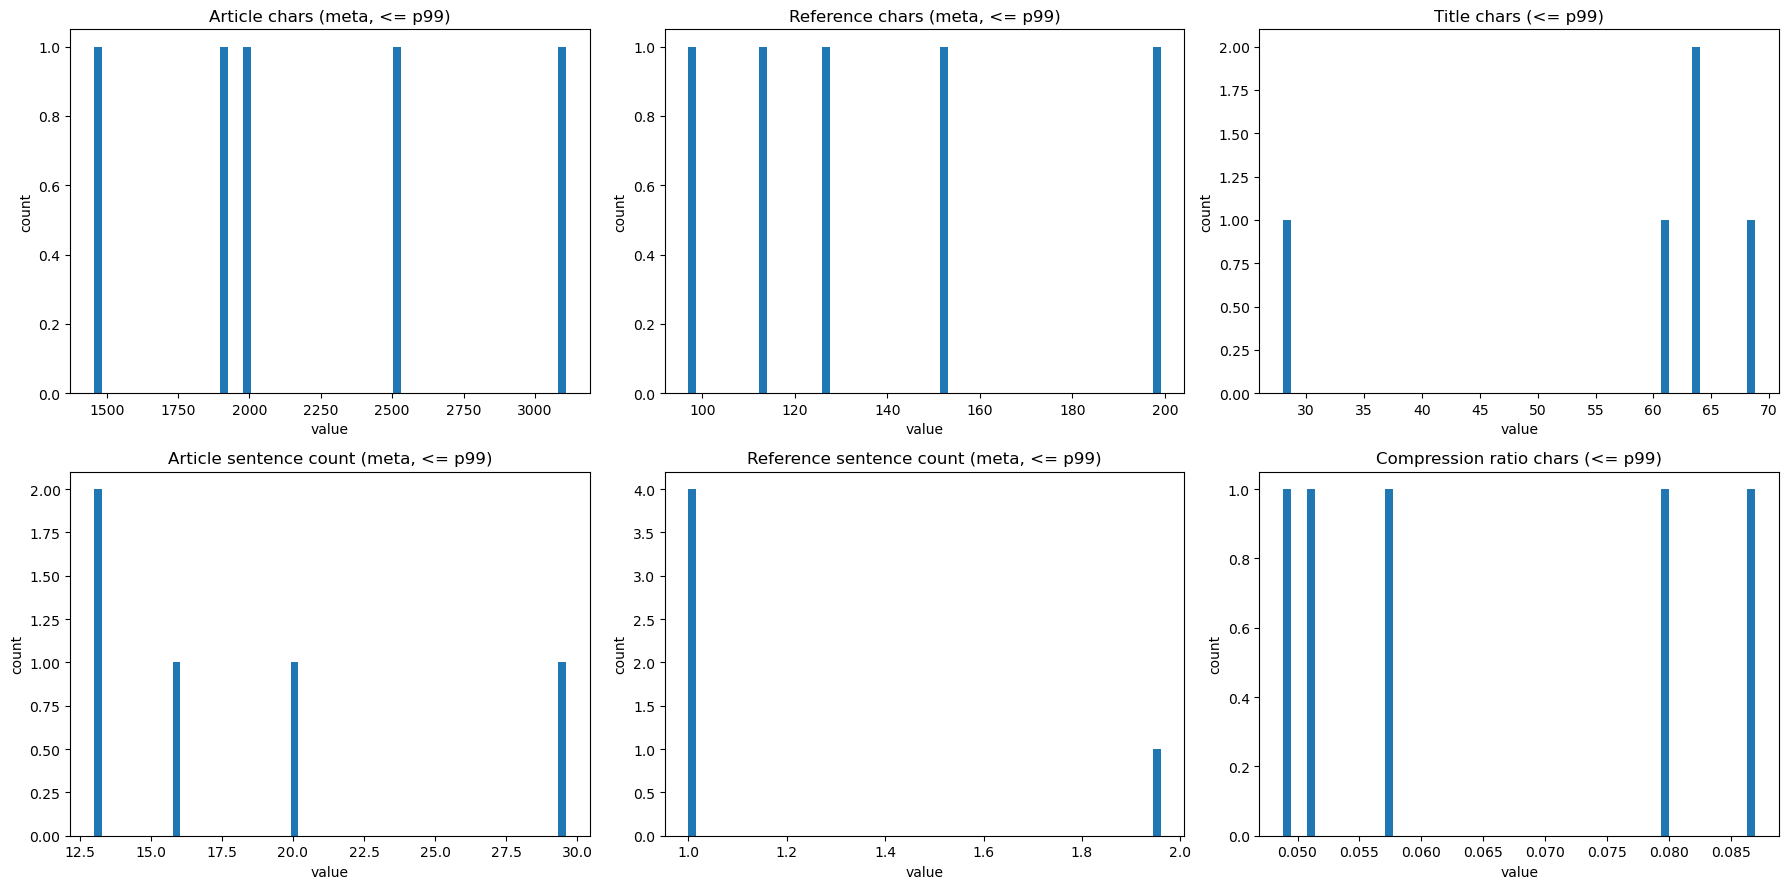

In [8]:
# 7) Distribution checks with histograms
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

axes[0, 0].hist(df["article_chars_meta"].clip(upper=df["article_chars_meta"].quantile(0.99)), bins=60)
axes[0, 0].set_title("Article chars (meta, <= p99)")

axes[0, 1].hist(df["reference_chars_meta"].clip(upper=df["reference_chars_meta"].quantile(0.99)), bins=60)
axes[0, 1].set_title("Reference chars (meta, <= p99)")

axes[0, 2].hist(df["title_chars"].clip(upper=df["title_chars"].quantile(0.99)), bins=60)
axes[0, 2].set_title("Title chars (<= p99)")

axes[1, 0].hist(df["article_sents_meta"].dropna().clip(upper=df["article_sents_meta"].quantile(0.99)), bins=60)
axes[1, 0].set_title("Article sentence count (meta, <= p99)")

axes[1, 1].hist(df["reference_sents_meta"].dropna().clip(upper=df["reference_sents_meta"].quantile(0.99)), bins=60)
axes[1, 1].set_title("Reference sentence count (meta, <= p99)")

axes[1, 2].hist(df["compression_ratio_chars"].clip(upper=df["compression_ratio_chars"].quantile(0.99)), bins=60)
axes[1, 2].set_title("Compression ratio chars (<= p99)")

for ax in axes.flat:
    ax.set_xlabel("value")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

In [9]:
# 8) Inspect random samples
SAMPLE_N = 5
sample_df = df.sample(n=min(SAMPLE_N, len(df)), random_state=SEED).copy()

display_cols = [
    "guid",
    "title",
    "article_chars_meta",
    "article_sents_meta",
    "reference_chars_meta",
    "reference_sents_meta",
    "compression_ratio_chars",
    "compression_ratio_sents",
]

sample_df[display_cols].sort_values("article_chars_meta", ascending=False)

,guid,title,article_chars_meta,article_sents_meta,reference_chars_meta,reference_sents_meta,compression_ratio_chars,compression_ratio_sents
3,74350,Chọn đúng nghề vẫn tốt hơn !,3133,30,153,1,0.048835,0.033333
4,82426,"Giữa biến_đổi khí_hậu , dân miền Tây ' Cùng xây cuộc_sống xanh '",2527,20,201,2,0.079541,0.100000
0,28757,Lý_do Jordan đề_nghị quân Chính_phủ Syria hoãn chiến_dịch ở Dara,1994,13,114,1,0.057172,0.076923
2,62167,Giá vàng hôm_nay ( 12/10 ) : Quay đầu giảm nhẹ trước cuộc họp của FED,1910,16,97,1,0.050785,0.062500
1,40014,Kim_Jong-un hôm_nay có_thể sang Nga họp thượng_đỉnh với Putin,1455,13,127,1,0.087285,0.076923


In [10]:
# Print 1-2 samples for manual inspection
for i, (_, row) in enumerate(sample_df.head(2).iterrows(), start=1):
    print("=" * 120)
    print(f"Sample #{i} | guid={row['guid']}")
    print("Title:", str(row["title"]))
    print("-" * 120)
    print("Article preview:")
    print(str(row["article"])[:1200], "...")
    print("-" * 120)
    print("Ground-truth reference summary:")
    print(str(row["reference_summary"]))
    print("-" * 120)
    print(
        f"article_chars={row['article_chars_meta']}, article_sents={row['article_sents_meta']}, "
        f"reference_chars={row['reference_chars_meta']}, reference_sents={row['reference_sents_meta']}, "
        f"ratio_chars={row['compression_ratio_chars']:.4f}, ratio_sents={row['compression_ratio_sents']:.4f}"
    )

Sample #1 | guid=40014
Title: Kim_Jong-un hôm_nay có_thể sang Nga họp thượng_đỉnh với Putin
------------------------------------------------------------------------------------------------------------------------
Article preview:
Tổng_thống Nga_Putin ( trái ) và lãnh_đạo Triều_Tiên_Kim_Jong-un . Hãng thông_tấn trung_ương Triều_Tiên KCNA hôm_nay xác_nhận lãnh_đạo Kim_Jong-un " sẽ sớm thăm Liên_bang Nga theo lời mời " của Tổng_thống Vladimir_Putin . " Hai lãnh_đạo sẽ có cuộc hội_đàm trong chuyến thăm này " , KCNA thông_báo , song không xác_định thời_gian hay địa_điểm diễn ra cuộc gặp . Trong khi đó , tờ Chosun_Ilbo của Hàn_Quốc đưa tin Kim_Jong-un hôm_nay sẽ lên tàu_hoả rời Bình_Nhưỡng để tới thành_phố Vladivostok thuộc miền Viễn_Đông của Nga . Hành_trình 700 km từ Bình_Nhưỡng đến Vladivostok mất khoảng 10-15 giờ . Điện Kremlin tuần trước cho_biết hai lãnh_đạo sẽ gặp nhau ở Nga " vào nửa cuối tháng 4 " nhưng không cung_cấp thêm thông_tin chi_tiết . Theo giới quan_sát , Putin và Kim_Jong-

In [11]:
# 9) Final answers to the 3 project questions
article_empty_ratio = float(schema_df.loc[schema_df["column"] == "article", "empty_ratio"].iloc[0])
reference_empty_ratio = float(schema_df.loc[schema_df["column"] == "reference_summary", "empty_ratio"].iloc[0])
meta_keys_full = bool((meta_schema_df["present_ratio"] == 1.0).all())

preprocessing_consistent = (
    preprocess_check["article_char_mismatch"] == 0
    and preprocess_check["reference_char_mismatch"] == 0
    and preprocess_check["article_sentence_mismatch"] == 0
    and preprocess_check["reference_sentence_mismatch"] == 0
)

distribution_summary = {
    "article_chars_p50": float(df["article_chars_meta"].quantile(0.50)),
    "article_chars_p90": float(df["article_chars_meta"].quantile(0.90)),
    "reference_chars_p50": float(df["reference_chars_meta"].quantile(0.50)),
    "compression_ratio_chars_mean": float(df["compression_ratio_chars"].mean()),
    "compression_ratio_chars_p90": float(df["compression_ratio_chars"].quantile(0.90)),
}

conclusion = {
    "q1_is_data_healthy": {
        "required_columns_present": len(missing_cols) == 0,
        "meta_keys_complete": meta_keys_full,
        "empty_ratio_article": article_empty_ratio,
        "empty_ratio_reference_summary": reference_empty_ratio,
    },
    "q2_is_preprocessing_correct": {
        "checked_sample_size": PREPROCESS_CHECK_N,
        "preprocessing_consistent": preprocessing_consistent,
        "mismatch_detail": preprocess_check,
    },
    "q3_is_distribution_reasonable": distribution_summary,
}

conclusion

{'q1_is_data_healthy': {'required_columns_present': True,
  'meta_keys_complete': True,
  'empty_ratio_article': 0.0,
  'empty_ratio_reference_summary': 0.0},
 'q2_is_preprocessing_correct': {'checked_sample_size': 5,
  'preprocessing_consistent': False,
  'mismatch_detail': {'sample_size': 5,
   'manifest_protocol_version': 'phase0_v1',
   'article_char_mismatch': 0,
   'reference_char_mismatch': 0,
   'article_sentence_mismatch': 2,
   'reference_sentence_mismatch': 0,
   'protocol_version_mismatch': 0}},
 'q3_is_distribution_reasonable': {'article_chars_p50': 1994.0,
  'article_chars_p90': 2890.6,
  'reference_chars_p50': 127.0,
  'compression_ratio_chars_mean': 0.06472360366554133,
  'compression_ratio_chars_p90': 0.08418751708353901}}

In [12]:
# 10) Optional: save run summary as JSON artifact
from datetime import datetime

report_dir = REPO_ROOT / "notebooks" / "results"
report_dir.mkdir(parents=True, exist_ok=True)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = report_dir / f"vietnews_data_check_summary_{TARGET_SPLIT}_{ts}.json"

summary_payload = {
    "target_split": TARGET_SPLIT,
    "rows": int(len(df)),
    "manifest_path": str(MANIFEST_PATH),
    "manifest_protocol_version": manifest.get("protocol_version"),
    "manifest_global_stats": manifest.get("global_stats", {}),
    "manifest_split_stats": (manifest.get("splits") or {}).get(TARGET_SPLIT, {}),
    "schema": schema_df.to_dict(orient="records"),
    "meta_schema": meta_schema_df.to_dict(orient="records"),
    "length_stats": length_stats.to_dict(orient="records"),
    "sentence_stats": sentence_stats.to_dict(orient="records"),
    "compression_stats": compression_stats.to_dict(orient="records"),
    "preprocess_check": preprocess_check,
    "conclusion": conclusion,
}

with out_path.open("w", encoding="utf-8") as f:
    json.dump(summary_payload, f, ensure_ascii=False, indent=2)

print("Saved summary:", out_path)

Saved summary: C:\Users\OS\OneDrive\Desktop\Text_Summarization\notebooks\results\vietnews_data_check_summary_train_20260417_233834.json
